---

# LESSON 18: STACKED LINE CHARTS

---

>---
>Use `stackplot()` to create a **stacked line chart**, which lets you visualize the overall trend over time, as well as its composition by series.
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style=('whitegrid')

In [2]:
df = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin'])

df = (df
    .pivot_table(index='period_begin', columns='region_name', 
                    values='inventory', aggfunc='sum')
    .resample('W').sum().round()
)

display(df.head(3), df.tail(3))
df.info()

region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2017-01-08,15492.0,5468.0,626.0
2017-01-15,15605.0,5493.0,652.0
2017-01-22,15724.0,5520.0,673.0


region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2022-04-17,11830.0,3449.0,1351.0
2022-04-24,12049.0,3613.0,1371.0
2022-05-01,12234.0,3748.0,1385.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 278 entries, 2017-01-08 to 2022-05-01
Freq: W-SUN
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Los Angeles    278 non-null    float64
 1   San Diego      278 non-null    float64
 2   San Francisco  278 non-null    float64
dtypes: float64(3)
memory usage: 8.7 KB


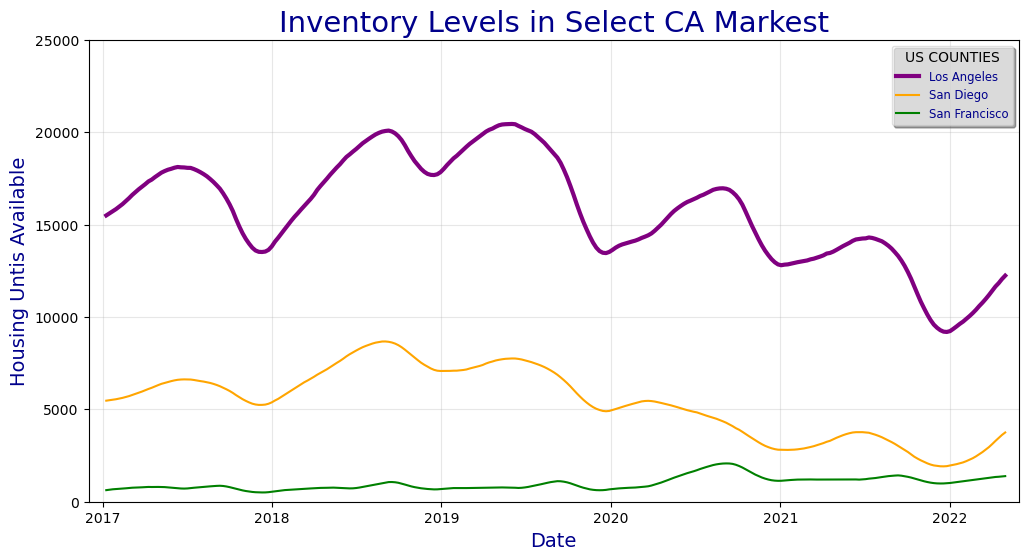

In [3]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

colors=['purple', 'orange', 'green']
width=[3, 1.5, 1.5]

for i, item in enumerate(df.columns):
    ax.plot(df[item], label=item, linewidth=width[i], color=colors[i])

ax.set_title('Inventory Levels in Select CA Markest', fontsize=21, color='darkblue')
ax.set_xlabel('Date', fontsize=14, color='darkblue')
ax.set_ylabel('Housing Untis Available', fontsize=14, color='darkblue')

ax.set_xlim(pd.Timestamp('2016-12-01'), pd.Timestamp('2022-05-30'))
ax.set_ylim(0, 25000)
# ax.set_xticks(df.index[::6])
# plt.xticks(rotation=90, fontsize=8)

plt.grid(alpha=0.3)

ax.legend(loc='upper right',
          title='US COUNTIES', title_fontsize='medium',
          fontsize='small', shadow=True, fancybox=True,
          framealpha=0.6, labelcolor='darkblue')

plt.show()

<br><br>

---

In [4]:
df.head(3)

region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2017-01-08,15492.0,5468.0,626.0
2017-01-15,15605.0,5493.0,652.0
2017-01-22,15724.0,5520.0,673.0


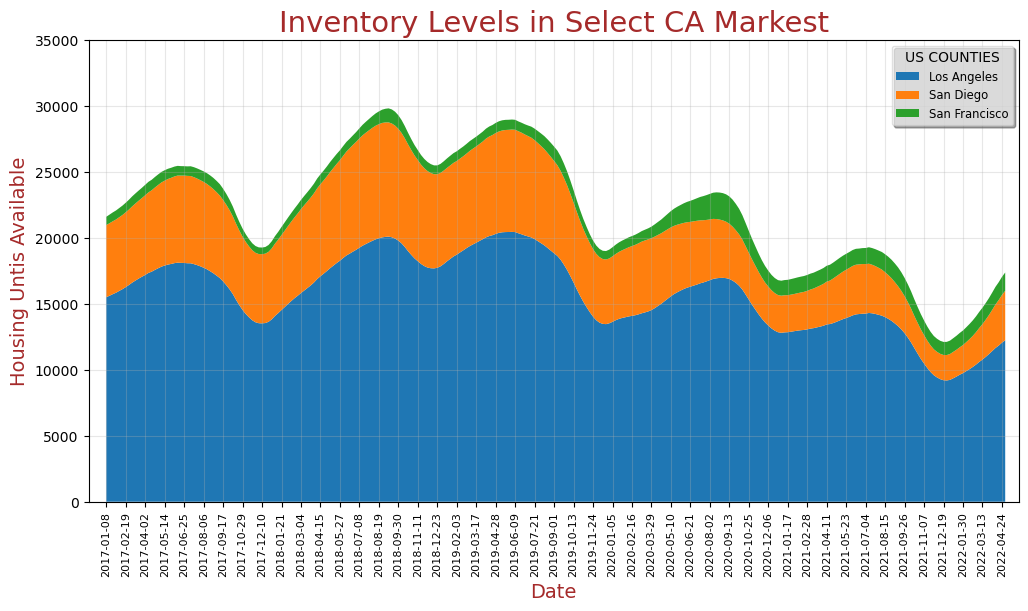

In [5]:
fix, ax = plt.subplots(figsize=(12, 6), dpi=100)

ax.stackplot(df.index,
             df['Los Angeles'], 
             df['San Diego'],
             df['San Francisco']
            )

ax.set_title('Inventory Levels in Select CA Markest', fontsize=21, color='brown')
ax.set_xlabel('Date', fontsize=14, color='brown')
ax.set_ylabel('Housing Untis Available', fontsize=14, color='brown')

ax.set_xlim(pd.Timestamp('2016-12-01'), pd.Timestamp('2022-05-30'))
ax.set_ylim(0, 35000)
ax.set_xticks(df.index[::6])
plt.xticks(rotation=90, fontsize=8)

plt.grid(alpha=0.3)

ax.legend(df.columns, loc='upper right',
          title='US COUNTIES', title_fontsize='medium',
          fontsize='small', shadow=True, fancybox=True,
          framealpha=0.6, labelcolor='black')

plt.show()

<br><br>

---

In [6]:
lab = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin'])

lab = (lab
    .pivot_table(index='period_begin', columns='region_name', 
                 values='median_active_list_price', aggfunc='mean')
    .resample('W').mean().round())

display(lab.head(3), lab.tail(3))
lab.info()

region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2017-01-08,611561.0,618571.0,1229019.0
2017-01-15,614061.0,621738.0,1233394.0
2017-01-22,617311.0,625821.0,1239977.0


region_name,Los Angeles,San Diego,San Francisco
period_begin,,,
2022-04-17,906782.0,902900.0,1290250.0
2022-04-24,906786.0,901983.0,1294000.0
2022-05-01,906745.0,901916.0,1295750.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 278 entries, 2017-01-08 to 2022-05-01
Freq: W-SUN
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Los Angeles    278 non-null    float64
 1   San Diego      278 non-null    float64
 2   San Francisco  278 non-null    float64
dtypes: float64(3)
memory usage: 8.7 KB


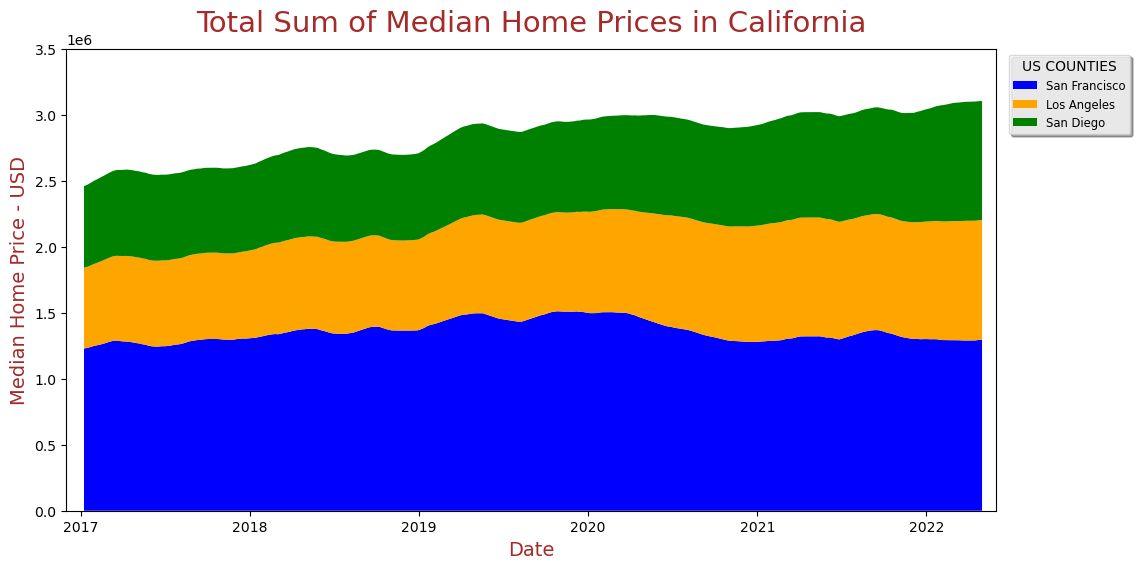

In [7]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

plot_colors=['blue', 'orange', 'green']

ax.stackplot(lab.index, 
             lab['San Francisco'],
             lab['Los Angeles'],
             lab['San Diego'],
             colors=plot_colors,
            )

ax.set_title('Total Sum of Median Home Prices in California', y=1.02,
             fontsize=21, color='brown')
ax.set_xlabel('Date', fontsize=14, color='brown')
ax.set_ylabel('Median Home Price - USD', fontsize=14, color='brown')

ax.set_xlim(pd.Timestamp('2016-12-01'), pd.Timestamp('2022-06-01'))
ax.set_ylim(0, 3500000)

ax.legend(['San Francisco', 'Los Angeles', 'San Diego'], 
          bbox_to_anchor=(1.15, 1),
          title='US COUNTIES',
          title_fontsize='medium',
          fontsize='small',
          shadow=True,
          framealpha=0.75
         )

plt.show()

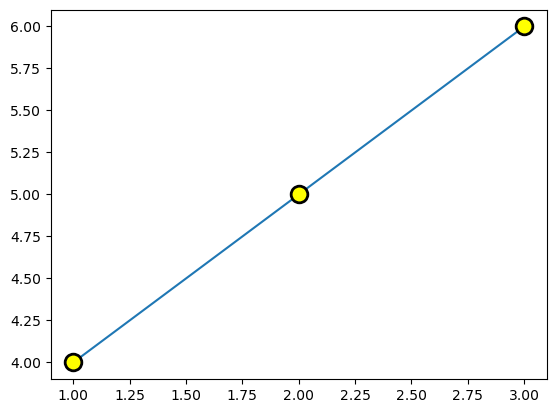

In [8]:
plt.plot([1, 2, 3], [4, 5, 6], 
         marker='o', 
         markersize=12, 
         markerfacecolor='yellow', 
         markeredgecolor='black', 
         markeredgewidth=2)
